In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from nltk.corpus import stopwords

from sklearn.svm import SVC
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Загрузка данных
df = pd.read_csv('movie_for_ml.csv')

In [3]:
df.head()

,tokenize_text
0,ограбление лосанджелес дерзкий ограбление неул...
1,удача веселие сдохнуть вечером обычный закусоч...
2,острый козырёк бессмертный человек 1940 разгар...
3,чебурашка 2 чебурашка жить ген ушастик взросле...
4,король шут навсегда панквселенная « король шут...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   tokenize_text  500 non-null    object
dtypes: object(1)
memory usage: 4.0+ KB


## Векторизация текста

In [5]:
russian_stopwords = stopwords.words("russian") 
russian_stopwords.extend(['т.д.', 'т', 'д', 'это','который','свой','своём','всем','всё','её','оба','ещё','должный']) 

In [6]:
# TF-IDF векторизация
vectorizer = TfidfVectorizer(
    max_features=5000,  
    min_df=2,           
    max_df=0.95,        
    ngram_range=(1, 3),  
    stop_words=russian_stopwords      
)

tfidf_matrix = vectorizer.fit_transform(df['tokenize_text'])
print(f"Размер TF-IDF матрицы: {tfidf_matrix.shape}")
print(f"Количество признаков: {len(vectorizer.get_feature_names_out())}")

Размер TF-IDF матрицы: (500, 5000)
Количество признаков: 5000


## Определение оптимального количества кластеров

In [7]:
from sklearn.decomposition import NMF

In [8]:
# создание модели NMF
nmf_model = NMF(n_components=5, random_state=0)
nmf_model.fit(tfidf_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: друг, жизнь, парень, дом, семья, жить, решать, девушка, родитель, новый
Topic 1: гарри, поттер, гарри поттер, хогвартс, школа, волшебник, курс школа чародейство, чародейство волшебство хогвартс, волшебство хогвартс, чародейство волшебство
Topic 2: джек, элизабет, капитан, пират, море, уилла, пират карибский, пират карибский море, карибский, карибский море
Topic 3: человек, мир, время, земля, весь, человечество, война, пытаться, мочь, команда
Topic 4: кольцо, средиземье, братство, властелин кольцо, властелин, бильбо, саурон, уничтожить, хоббит, всевластие


In [9]:
nmf_model = NMF(n_components=7, random_state=0)
nmf_model.fit(tfidf_matrix)

for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: мир, семья, весь, девушка, жизнь, дом, стать, самый, становиться, решать
Topic 1: гарри, поттер, гарри поттер, хогвартс, школа, волшебник, чародейство волшебство, школа чародейство, курс школа, курс школа чародейство
Topic 2: джек, элизабет, капитан, пират, море, уилла, карибский, карибский море, пират карибский, пират карибский море
Topic 3: человек, время, земля, человечество, война, будущее, сын, мочь, катастрофа, машина
Topic 4: кольцо, средиземье, братство, властелин кольцо, властелин, бильбо, саурон, уничтожить, хоббит, кольцо всевластие
Topic 5: питер, человекпаук, паркер, питер паркер, супергерой, вселенная, человекапаук, весь, вместе, галактика
Topic 6: друг, друг друг, жизнь, приключение, кот, родитель, новый, парень, очень, брат


In [10]:
X_topics_nmf = nmf_model.fit_transform(tfidf_matrix)

df['topic_nmf'] = np.argmax(X_topics_nmf, axis=1)

In [11]:
df.head(10)

,tokenize_text,topic_nmf
0,ограбление лосанджелес дерзкий ограбление неул...,0
1,удача веселие сдохнуть вечером обычный закусоч...,3
2,острый козырёк бессмертный человек 1940 разгар...,3
3,чебурашка 2 чебурашка жить ген ушастик взросле...,6
4,король шут навсегда панквселенная « король шут...,6
5,баллада война лето 2022 группа доброволец разв...,6
6,аватар пламя пепел джейк салли нейтири ребёнок...,0
7,левша россия конец xix век фон надвигаться вой...,0
8,крик 7 сидень прескотт жить семья тихий городо...,0
9,казнить помиловать близкий будущее лосанджелес...,0


In [12]:
df['topic_nmf'].value_counts()

topic_nmf
0    213
3    126
6     95
5     28
1     16
4     12
2     10
Name: count, dtype: int64

Расчет метрик для разных K...
Обработка K=2...


  File "C:\Users\rafael\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\rafael\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\rafael\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\rafael\anaconda3\Lib\subproc

  K=2: WCSS=489.56, Silhouette=0.0023
Обработка K=3...
  K=3: WCSS=487.66, Silhouette=0.0030
Обработка K=4...
  K=4: WCSS=484.59, Silhouette=0.0055
Обработка K=5...
  K=5: WCSS=484.43, Silhouette=0.0040
Обработка K=6...
  K=6: WCSS=481.61, Silhouette=0.0062
Обработка K=7...
  K=7: WCSS=479.82, Silhouette=0.0070
Обработка K=8...
  K=8: WCSS=478.13, Silhouette=0.0080
Обработка K=9...
  K=9: WCSS=475.77, Silhouette=0.0092
Обработка K=10...
  K=10: WCSS=474.80, Silhouette=0.0092


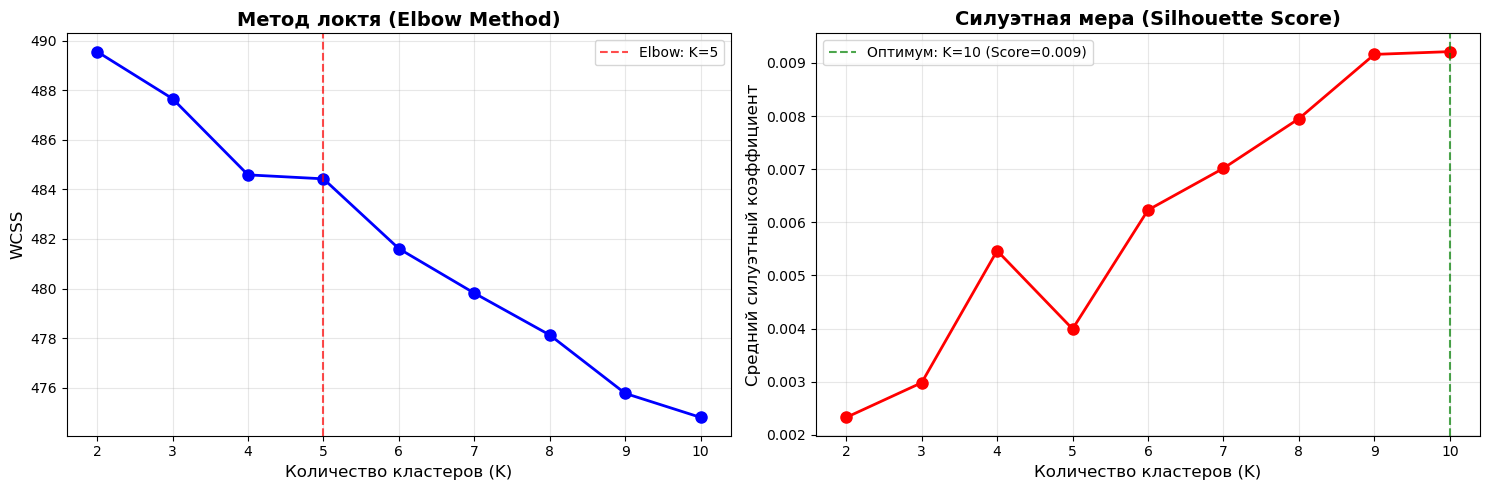


ОПТИМАЛЬНОЕ КОЛИЧЕСТВО КЛАСТЕРОВ: 10
Лучший силуэтный коэффициент: 0.0092

Интерпретация:
✗ Случайная кластеризация


In [13]:
# Расчет WCSS и силуэтных оценок
wcss = []
silhouette_scores = []

# Для силуэта нужно минимум 2 кластера
K_range = range(2, 11)  # От 2 до 10 кластеров

print("Расчет метрик для разных K...")
for k in K_range:
    print(f"Обработка K={k}...")
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(tfidf_matrix)
    
    # WCSS
    wcss.append(kmeans.inertia_)
    
    # Силуэтная мера (на выборке, так как полная матрица может быть большой)
    if tfidf_matrix.shape[0] > 5000:
        # Для больших данных берем выборку
        sample_size = min(5000, tfidf_matrix.shape[0])
        indices = np.random.choice(tfidf_matrix.shape[0], sample_size, replace=False)
        silhouette_avg = silhouette_score(tfidf_matrix[indices], cluster_labels[indices])
    else:
        silhouette_avg = silhouette_score(tfidf_matrix, cluster_labels)
    
    silhouette_scores.append(silhouette_avg)
    print(f"  K={k}: WCSS={kmeans.inertia_:.2f}, Silhouette={silhouette_avg:.4f}")

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Метод локтя
ax1.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
ax1.set_title('Метод локтя (Elbow Method)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Количество кластеров (K)', fontsize=12)
ax1.set_ylabel('WCSS', fontsize=12)
ax1.grid(True, alpha=0.3)

# Находим точку перегиба (elbow)
if len(wcss) > 2:
    deltas = np.diff(wcss)
    delta2_deltas = np.diff(deltas)
    elbow_k = K_range[np.argmin(delta2_deltas) + 1] if len(delta2_deltas) > 0 else K_range[np.argmin(deltas)]
    ax1.axvline(x=elbow_k, color='red', linestyle='--', alpha=0.7, label=f'Elbow: K={elbow_k}')
    ax1.legend()

# Силуэтная мера
ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_title('Силуэтная мера (Silhouette Score)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Количество кластеров (K)', fontsize=12)
ax2.set_ylabel('Средний силуэтный коэффициент', fontsize=12)
ax2.grid(True, alpha=0.3)

best_k_silhouette = K_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
ax2.axvline(x=best_k_silhouette, color='green', linestyle='--', alpha=0.7, 
            label=f'Оптимум: K={best_k_silhouette} (Score={best_score:.3f})')
ax2.legend()

plt.tight_layout()
plt.show()

# Выбор оптимального K
optimal_k = best_k_silhouette  # Используем optimal_k = best_k_silhouette
print(f"\n{'='*50}")
print(f"ОПТИМАЛЬНОЕ КОЛИЧЕСТВО КЛАСТЕРОВ: {optimal_k}")
print(f"{'='*50}")
print(f"Лучший силуэтный коэффициент: {best_score:.4f}")
print(f"\nИнтерпретация:")
if best_score > 0.7:
    print("✓ Отличная кластеризация")
elif best_score > 0.5:
    print("✓ Хорошая кластеризация")
elif best_score > 0.25:
    print("⚠ Слабая кластеризация")
else:
    print("✗ Случайная кластеризация")

In [14]:
n_topics = 7
nmf_transformed = nmf_model.transform(tfidf_matrix)

print("="*50)
print("ПРОВЕРКА КЛАСТЕРИЗАЦИИ: ТОП-ПРИМЕРЫ ТЕКСТОВ ПО ТЕМАМ")
print("="*50)

for topic_idx in range(n_topics):
    topic_scores = nmf_transformed[:, topic_idx]
    
    top_docs_idx = np.argsort(topic_scores)[-3:][::-1]
    
    print(f"ТЕМА №{topic_idx}")
    
    for rank, doc_idx in enumerate(top_docs_idx, 1):
        full_text = df.iloc[doc_idx]['tokenize_text']
        preview_text = (full_text[:100] + '...') if len(full_text) > 100 else full_text
        
        score = topic_scores[doc_idx]
        
        print(f"  {rank}. Текст: {preview_text}")
        print(f"     Уверенность алгоритма: {score:.4f}")
    print("-" * 30)

ПРОВЕРКА КЛАСТЕРИЗАЦИИ: ТОП-ПРИМЕРЫ ТЕКСТОВ ПО ТЕМАМ
ТЕМА №0
  1. Текст: шоу трумана представить начинать понимать вокруг декорация человек актёр притворяться казаться весь ...
     Уверенность алгоритма: 0.1598
  2. Текст: ругаться 1983 пятнадцатилетний джон дэвидсон жить семья простой рабочий шотландский городок галашилс...
     Уверенность алгоритма: 0.1491
  3. Текст: тёща ольга николаевич – волевой женщина начальница жкх вполне довольный жизнь хозяйка дом работа пол...
     Уверенность алгоритма: 0.1421
------------------------------
ТЕМА №1
  1. Текст: гарри поттер тайный комната гарри поттер переходить второй курс школа чародейство волшебство хогварт...
     Уверенность алгоритма: 0.5061
  2. Текст: гарри поттер тайный комната гарри поттер переходить второй курс школа чародейство волшебство хогварт...
     Уверенность алгоритма: 0.5061
  3. Текст: гарри поттер кубок огонь гарри поттер рон гермиона возвращаться четвёртый курс школа чародейство вол...
     Уверенность алгоритма: 0

## Классификация

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['tokenize_text'], df['topic_nmf'], 
                                                      test_size=0.3, 
                                                      random_state=0)

In [16]:
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [17]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [18]:
model_lr = LogisticRegression()
model_lr.fit(X_train_tfidf, y_train)

LogisticRegression()

In [19]:
y_pred = model_lr.predict(X_test_tfidf)

In [20]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.54      1.00      0.70        64
           1       1.00      0.20      0.33         5
           2       0.00      0.00      0.00         4
           3       0.95      0.53      0.68        36
           4       0.00      0.00      0.00         4
           5       1.00      0.11      0.20         9
           6       1.00      0.36      0.53        28

    accuracy                           0.63       150
   macro avg       0.64      0.31      0.35       150
weighted avg       0.74      0.63      0.58       150



In [21]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train_tfidf, y_train)

RandomForestClassifier()

In [22]:
y_pred = model_rf.predict(X_test_tfidf)

In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.98      0.80        64
           1       1.00      0.80      0.89         5
           2       1.00      1.00      1.00         4
           3       1.00      0.64      0.78        36
           4       1.00      0.50      0.67         4
           5       1.00      0.56      0.71         9
           6       0.94      0.61      0.74        28

    accuracy                           0.79       150
   macro avg       0.94      0.73      0.80       150
weighted avg       0.85      0.79      0.78       150



In [24]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train_tfidf, y_train)

KNeighborsClassifier()

In [25]:
y_pred = model_knn.predict(X_test_tfidf)

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.89      0.78        64
           1       1.00      0.80      0.89         5
           2       1.00      1.00      1.00         4
           3       0.61      0.61      0.61        36
           4       1.00      0.50      0.67         4
           5       1.00      0.56      0.71         9
           6       0.82      0.50      0.62        28

    accuracy                           0.72       150
   macro avg       0.88      0.69      0.75       150
weighted avg       0.74      0.72      0.71       150



## Сохранение моделей

In [27]:
import pickle

with open('model_rf.pkl', 'wb') as f:
    pickle.dump(model_rf, f)

In [28]:
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

In [29]:
df.to_csv('data_movies2_classification_regression.csv')

In [30]:
df.head()

,tokenize_text,topic_nmf
0,ограбление лосанджелес дерзкий ограбление неул...,0
1,удача веселие сдохнуть вечером обычный закусоч...,3
2,острый козырёк бессмертный человек 1940 разгар...,3
3,чебурашка 2 чебурашка жить ген ушастик взросле...,6
4,король шут навсегда панквселенная « король шут...,6


## Проверка модели

In [31]:
import pickle
import joblib
import pandas as pd
import string
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pymorphy3
from sklearn.feature_extraction.text import TfidfVectorizer

In [32]:
with open('model_rf.pkl', 'rb') as file:
    model = pickle.load(file)

with open('vectorizer.pkl', 'rb') as file:
    vectorizer = pickle.load(file)

FileNotFoundError: [Errno 2] No such file or directory: 'model_rf_movie.pkl'

In [ ]:
def fun_punctuation_text(text):
    text = text.lower()
    text = ''.join([ch for ch in text if ch not in string.punctuation])
    text = ''.join([i if not i.isdigit() else '' for i in text])
    text = ''.join([i if i.isalpha() else ' ' for i in text])
    text = re.sub(r'\s+', ' ', text, flags=re.I)
    text = re.sub('[a-z]', '', text, flags=re.I)
    st = '❯\xa0'
    text = ''.join([ch if ch not in st else ' ' for ch in text])
    return text

In [ ]:
def fun_lemmatizing_text(text):
    tokens = word_tokenize(text)
    res = list()
    for word in tokens:
        p = pymorphy3.MorphAnalyzer(lang='ru').parse(word)[0]
        res.append(p.normal_form)  
    text = " ".join(res)
    return text

In [ ]:
def fun_tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords]
    text = " ".join(tokens)
    return text

In [ ]:
t1 = "Один ушлый американец ещё со студенческих лет приторговывал наркотиками, а теперь придумал схему нелегального обогащения с использованием поместий обедневшей английской аристократии и очень неплохо на этом разбогател. Другой пронырливый журналист приходит к Рэю, правой руке американца, и предлагает тому купить киносценарий, в котором подробно описаны преступления его босса при участии других представителей лондонского криминального мира — партнёра-еврея, китайской диаспоры, чернокожих спортсменов и даже русского олигарха."

In [ ]:
t2 = "21 июня 1941 года. Молодой лейтенант Коля Плужников, получив назначение на постоянное место службы, приезжает в Брест. Переполненные залы ожидания вокзала и толпа увешанных багажом людей не настораживают охваченного радостными надеждами юношу. Коля спешит к месту расположения своей части — в Брестскую крепость… Солдата не успевают зачислить в личный состав военнослужащих, а в четыре утра раздаются артиллерийские разрывы — началась война. Он не был зачислен в ряды военнослужащих Брестской крепости, но всё равно принял участие в бою."

In [ ]:
t3 = "Российский ракетный подводный крейсер специального назначения бесследно исчезает во время секретной миссии в Гренландском море. На его поиски отправляется экипаж под командованием Виктора Воронина, чей старший брат командовал пропавшей субмариной. Перед моряками стоит задача любыми силами найти подлодку и не допустить, чтобы новое секретное оружие попало в руки врага. В это же время из-за геологических исследований на полярной станции в северных водах пробуждается Кракен — гигантское чудовище, способное сливаться с подводной тьмой, обладающее высоким интеллектом. Именно с ним предстоит столкнуться морякам, разыскивающим пропавшую подводную лодку."

In [ ]:
t4 = "Пострадав в результате несчастного случая, богатый аристократ Филипп нанимает в помощники человека, который менее всего подходит для этой работы, – молодого жителя предместья Дрисса, только что освободившегося из тюрьмы. Несмотря на то, что Филипп прикован к инвалидному креслу, Дриссу удается привнести в размеренную жизнь аристократа дух приключений."

In [ ]:
t5 = "Жизнь харизматичного авантюриста, капитана Джека Воробья, полная увлекательных приключений, резко меняется, когда его заклятый враг капитан Барбосса похищает корабль Джека Черную Жемчужину, а затем нападает на Порт Ройал и крадет прекрасную дочь губернатора Элизабет Свонн. Друг детства Элизабет Уилл Тернер вместе с Джеком возглавляет спасательную экспедицию на самом быстром корабле Британии, чтобы вызволить девушку и заодно отобрать у злодея Черную Жемчужину. Вслед за этой парочкой отправляется амбициозный коммодор Норрингтон, который к тому же числится женихом Элизабет.Однако Уилл не знает, что над Барбоссой висит вечное проклятие, при лунном свете превращающее его с командой в живых скелетов. Проклятье будет снято лишь тогда, когда украденное золото Ацтеков будет возвращено пиратами на старое место."

In [ ]:
def predict_topic(text):
    text = fun_punctuation_text(text)
    text = fun_lemmatizing_text(text)
    text = fun_tokenize(text)
    text_vectorized = vectorizer.transform([text])
    prediction = model.predict(text_vectorized)
    probabilities = model.predict_proba(text_vectorized)
    return prediction, probabilities

In [ ]:
prediction, probabilities = predict_topic(t1)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

In [ ]:
prediction, probabilities = predict_topic(t2)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

In [ ]:
prediction, probabilities = predict_topic(t3)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

In [ ]:
prediction, probabilities = predict_topic(t4)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

In [ ]:
prediction, probabilities = predict_topic(t5)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

Topic 0 (Друзья, Семья, Жизнь): "друг, жизнь, парень, дом, семья..." — это драмы, истории про отношения и повседневность.

Topic 1 (Гарри Поттер): "гарри, поттер, хогвартс..." — тут без вариантов, волшебство и фэнтези (вселенная Гарри Поттера).

Topic 2 (Пираты): "джек, капитан, пират, море, карибский..." — приключения, морская тематика, пираты.

Topic 3 (Будущее, Война, Человечество): "человек, мир, земля, война, будущее, катастрофа..." — это глобальная фантастика, постапокалипсис или военные драмы.

Topic 4 (Властелин колец): "кольцо, средиземье, властелин, хоббит..." — эпическое фэнтези (Средиземье).

Topic 5 (Супергерои): "питер, человек-паук, паркер, супергерой, галактика..." — комиксы, супергероика, Marvel/DC.

Topic 6 (Дружба, Животные, Приключения): "друг, кот, родитель, приключение..." — скорее всего, детские фильмы, мультфильмы или семейные комедии.

Вывод: 
    Провели кластеризацию  и классификацию по данным фильмов , для просмотра, как модель будет относить к определенным группам